# Align Metrics Analysis

`DebugSfpDistancePolicy` 의 align 단계에서 기록한 CSV 를 로드/시각화/통계합니다.

## 컬럼 의미

| 컬럼 | 의미 | 단위 |
|------|------|------|
| `wall_time` | row 기록 시각 (epoch seconds) | s |
| `step` | align 루프 인덱스 (0부터) | - |
| `t_obs_ms` | `get_observation()` 호출 시간 | ms |
| `t_pred_ms` | `predict_offset_m()` 추론 wall-clock | ms |
| `t_cmd_ms` | `set_pose_target()` publish 시간 | ms |
| `drift_mm` | obs 시점 TCP vs 명령 직전 TCP 의 거리 norm | mm |
| `drift_d{x,y,z}_mm` | drift 의 base 좌표축별 분해 (부호 포함) | mm |
| `xy_base_mm` | 모델 예측 xy 오프셋 norm (정렬 진행도) | mm |
| `z_base_est_mm` | 모델 예측 z 오프셋 | mm |
| `stable_count` | 연속 안정 카운트 (ALIGN_STABLE_STEPS 도달 시 종료) | - |
| `pred_{x,y,z}_mm` | 모델 예측 offset_base 각 축 | mm |
| `cmd_xy_{x,y}_mm` | 실제로 보낸 xy step 명령 | mm |

## CSV 위치

기본: `~/aic_debug/align_metrics/align_<timestamp>_<task_label>.csv`

환경 변수 `AIC_DEBUG_ALIGN_METRICS_DIR` 로 변경 가능.

In [12]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.3f}")
plt.rcParams["figure.dpi"] = 110

## 1. CSV 파일 찾기

In [13]:
METRICS_DIR = Path(os.environ.get("AIC_DEBUG_ALIGN_METRICS_DIR", Path.home() / "aic_debug" / "align_metrics"))
csv_files = sorted(METRICS_DIR.glob("align_*.csv"))
print(f"directory: {METRICS_DIR}")
print(f"found {len(csv_files)} CSV files")
for f in csv_files[-10:]:
    size_kb = f.stat().st_size / 1024.0
    print(f"  {f.name}  ({size_kb:.1f} KB)")

directory: /home/vsc/aic_debug/align_metrics
found 3 CSV files
  align_20260516_044533_nic_card_mount_0_sfp_port_0.csv  (1.4 KB)
  align_20260516_044606_nic_card_mount_1_sfp_port_0.csv  (2.3 KB)
  align_20260516_044645_sc_port_1_sc_port_base.csv  (0.2 KB)


## 2. 로드 및 통합 DataFrame

In [14]:
# 분석 대상 선택: 최근 N개 또는 전체
N_RECENT = None  # None 이면 전체, 숫자면 최근 N 파일
selected = csv_files if N_RECENT is None else csv_files[-N_RECENT:]

dfs = []
for f in selected:
    df = pd.read_csv(f)
    df["source"] = f.stem
    df["task"] = f.stem.split("_", 3)[-1] if f.stem.count("_") >= 3 else f.stem
    dfs.append(df)

if not dfs:
    raise FileNotFoundError(f"No CSV files in {METRICS_DIR}")

df_all = pd.concat(dfs, ignore_index=True)
print(f"rows: {len(df_all)},  runs: {df_all['source'].nunique()}")
df_all.head()

rows: 9,  runs: 2


/tmp/ipykernel_450183/1921308546.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat(dfs, ignore_index=True)


,wall_time,step,t_obs_ms,t_pred_ms,t_cmd_ms,drift_mm,drift_dx_mm,drift_dy_mm,drift_dz_mm,xy_base_mm,...,pred_raw_x_mm,pred_raw_y_mm,pred_raw_z_mm,bias_x_mm,bias_y_mm,bias_z_mm,cmd_xy_x_mm,cmd_xy_y_mm,source,task
0,1778874335.386,0,0.002,45.300,0.171,0.008,0.002,0.000,0.008,1.814,...,0.668,1.687,-17.584,0.000,0.000,0.000,-0.434,-1.096,align_20260516_044533_nic_card_mount_0_sfp_port_0,nic_card_mount_0_sfp_port_0
1,1778874337.429,1,0.033,40.420,0.185,0.027,0.017,0.021,-0.000,1.711,...,0.293,1.685,-18.082,0.000,0.000,0.000,-0.190,-1.095,align_20260516_044533_nic_card_mount_0_sfp_port_0,nic_card_mount_0_sfp_port_0
2,1778874339.484,2,0.027,42.429,0.259,0.003,-0.003,-0.000,-0.001,1.735,...,0.141,1.729,-17.600,0.000,0.000,0.000,-0.091,-1.124,align_20260516_044533_nic_card_mount_0_sfp_port_0,nic_card_mount_0_sfp_port_0
3,1778874369.005,0,0.000,58.709,0.183,0.035,0.015,-0.018,-0.026,3.415,...,2.877,1.840,-19.093,0.000,0.000,0.000,-1.870,-1.196,align_20260516_044606_nic_card_mount_1_sfp_port_0,nic_card_mount_1_sfp_port_0
4,1778874371.060,1,0.032,51.869,0.207,0.047,-0.027,-0.025,-0.030,2.588,...,1.072,2.356,-17.801,0.000,0.000,0.000,-0.697,-1.531,align_20260516_044606_nic_card_mount_1_sfp_port_0,nic_card_mount_1_sfp_port_0


## 3. 요약 통계

In [15]:
summary_cols = ["t_obs_ms", "t_pred_ms", "t_cmd_ms", "drift_mm", "xy_base_mm"]
print("=== 전체 (step 포함) ===")
print(df_all[summary_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(3))

print("\n=== step > 0 (lazy init 제외) ===")
print(df_all[df_all["step"] > 0][summary_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(3))

=== 전체 (step 포함) ===
       t_obs_ms  t_pred_ms  t_cmd_ms  drift_mm  xy_base_mm
count     9.000      9.000     9.000     9.000       9.000
mean      0.022     43.131     0.199     0.020       1.848
std       0.016      8.022     0.029     0.019       0.932
min       0.000     32.136     0.171     0.000       0.196
50%       0.032     41.256     0.189     0.009       1.764
90%       0.034     53.237     0.239     0.047       2.754
95%       0.034     55.973     0.249     0.047       3.084
99%       0.035     58.162     0.257     0.047       3.349
max       0.035     58.709     0.259     0.047       3.415

=== step > 0 (lazy init 제외) ===
       t_obs_ms  t_pred_ms  t_cmd_ms  drift_mm  xy_base_mm
count     7.000      7.000     7.000     7.000       7.000
mean      0.028     40.595     0.205     0.020       1.629
std       0.012      6.089     0.031     0.020       0.832
min       0.002     32.136     0.172     0.000       0.196
50%       0.033     40.420     0.192     0.009       1.735
90

## 4. 추론 시간 추이 (t_pred over step)

- 첫 스텝이 다른 스텝보다 현저히 크면 **lazy init** 신호 → 워밍업 필요.
- 전반적 분산이 크면 GPU 컨텐션, 캐시 문제, batch 변동 등 의심.

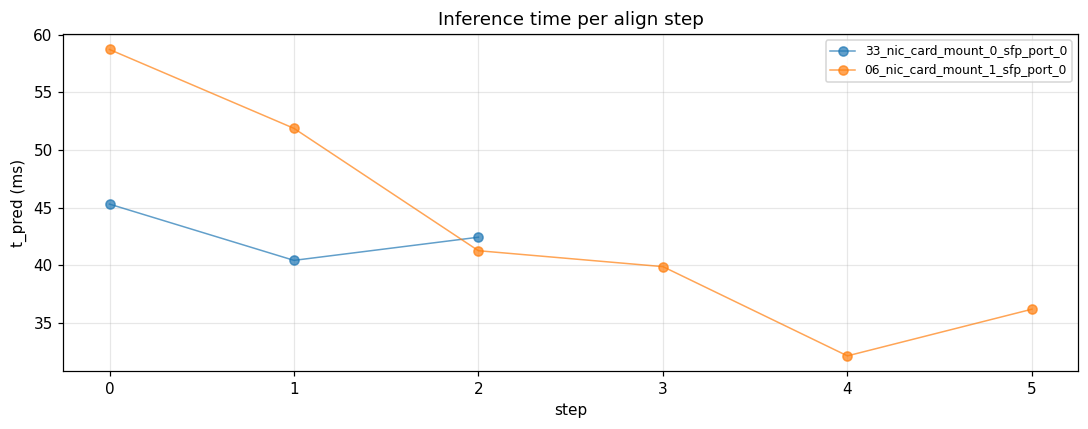

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
for src, g in df_all.groupby("source"):
    ax.plot(g["step"], g["t_pred_ms"], marker="o", linewidth=1.0, alpha=0.7, label=src[-30:])
ax.set_xlabel("step")
ax.set_ylabel("t_pred (ms)")
ax.set_title("Inference time per align step")
ax.grid(True, alpha=0.3)
if df_all["source"].nunique() <= 10:
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

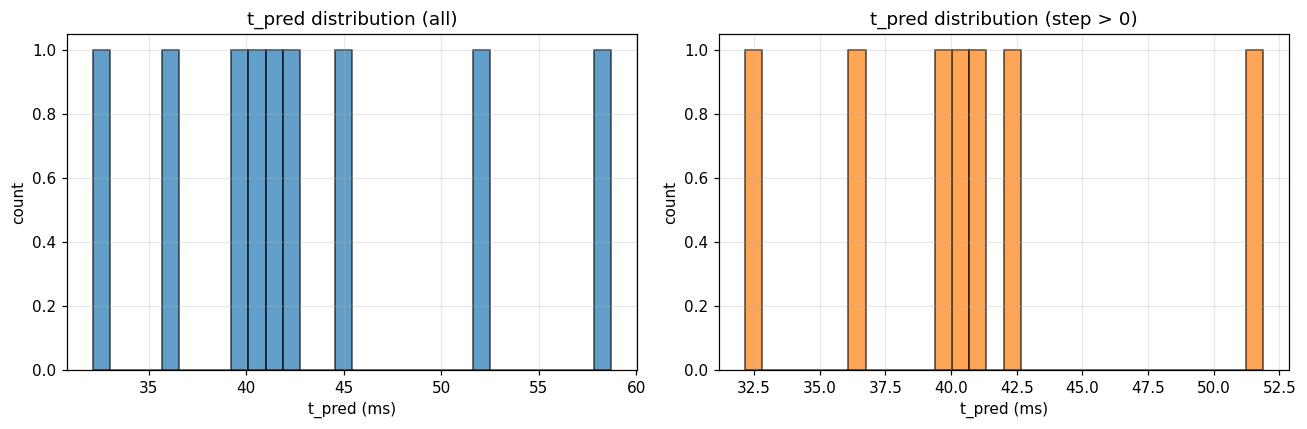

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_all["t_pred_ms"], bins=30, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("t_pred (ms)")
axes[0].set_ylabel("count")
axes[0].set_title("t_pred distribution (all)")
axes[0].grid(True, alpha=0.3)

df_warm = df_all[df_all["step"] > 0]
axes[1].hist(df_warm["t_pred_ms"], bins=30, edgecolor="black", alpha=0.7, color="C1")
axes[1].set_xlabel("t_pred (ms)")
axes[1].set_ylabel("count")
axes[1].set_title("t_pred distribution (step > 0)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Drift 추이

- drift 가 추론 시간 동안 로봇이 움직인 거리. 0 에 가까울수록 동기 추론 영향 적음.
- 일반적으로 첫 스텝에서 큼 (이전 단계 잔여 모션 + lazy init).

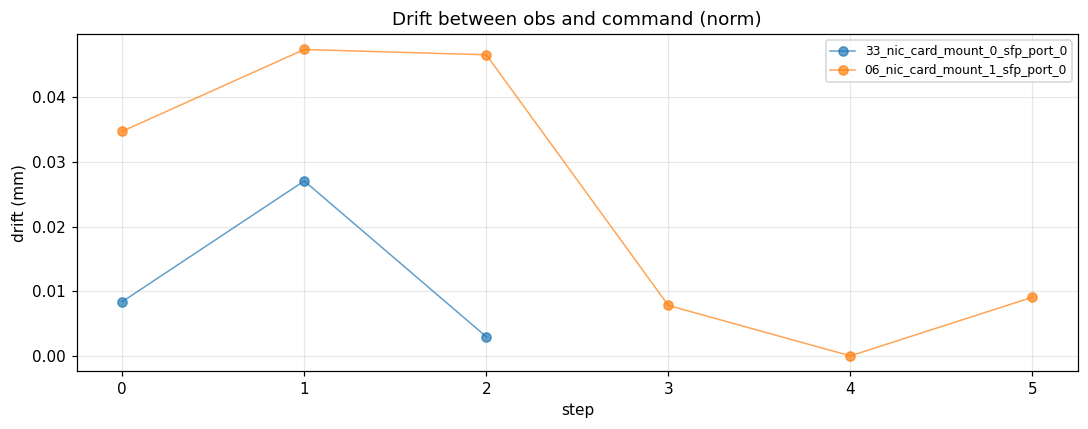

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
for src, g in df_all.groupby("source"):
    ax.plot(g["step"], g["drift_mm"], marker="o", linewidth=1.0, alpha=0.7, label=src[-30:])
ax.set_xlabel("step")
ax.set_ylabel("drift (mm)")
ax.set_title("Drift between obs and command (norm)")
ax.grid(True, alpha=0.3)
if df_all["source"].nunique() <= 10:
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

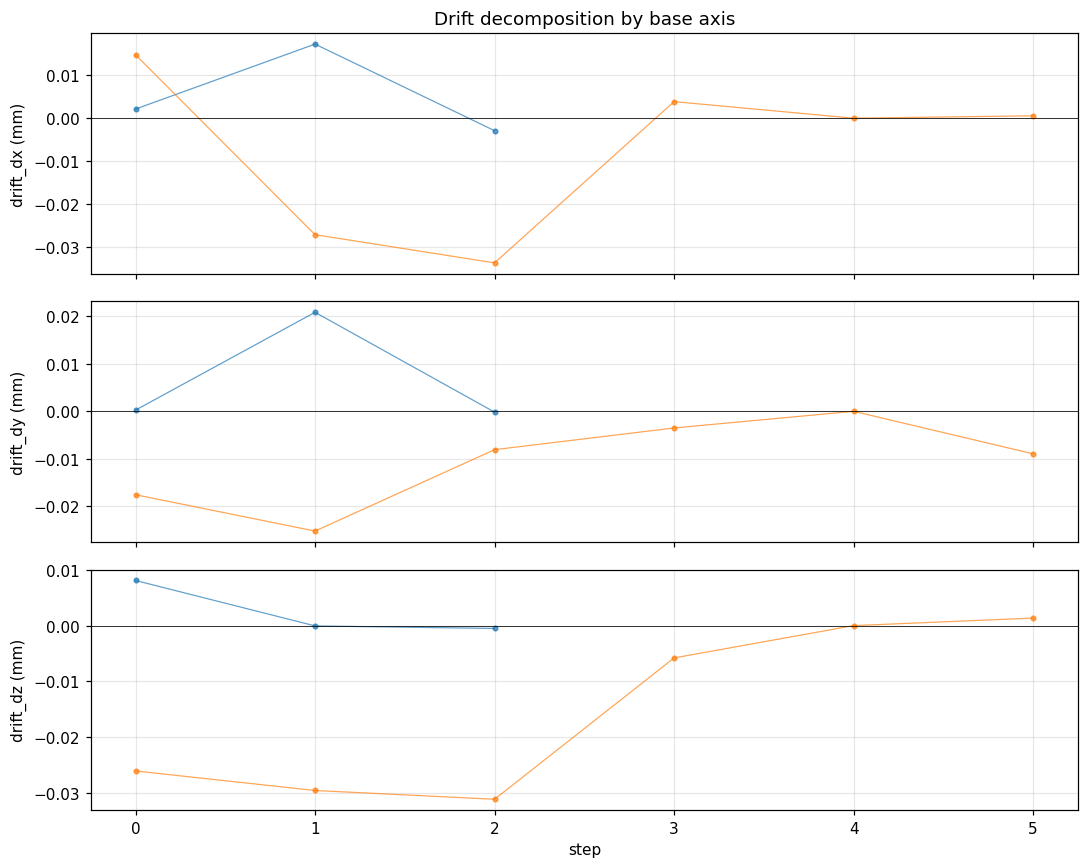

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for axis_name, ax in zip(["dx", "dy", "dz"], axes):
    for src, g in df_all.groupby("source"):
        ax.plot(g["step"], g[f"drift_{axis_name}_mm"], marker=".", linewidth=0.8, alpha=0.7, label=src[-25:])
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel(f"drift_{axis_name} (mm)")
    ax.grid(True, alpha=0.3)
axes[2].set_xlabel("step")
axes[0].set_title("Drift decomposition by base axis")
plt.tight_layout()
plt.show()

## 6. Drift vs t_pred 상관

추론이 길어질수록 drift 가 커지는 경향이 있으면 → 동기 실행이 원인일 가능성 높음.

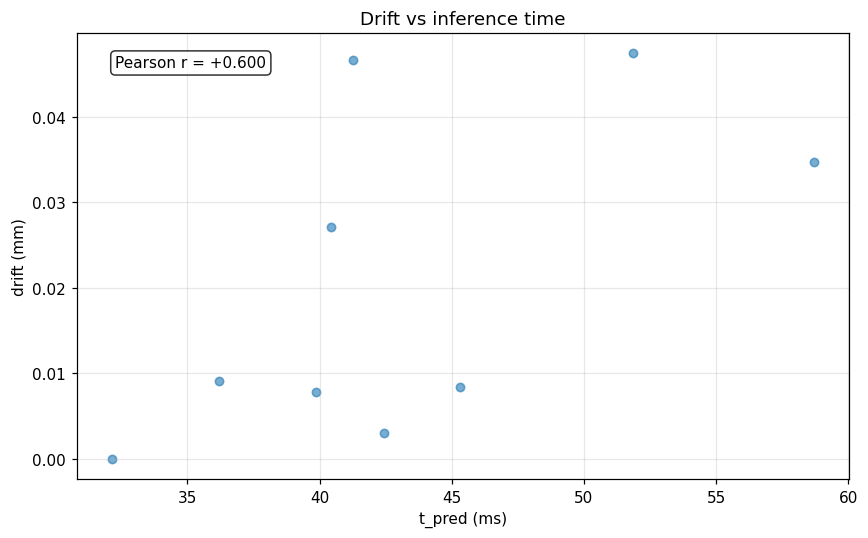

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_all["t_pred_ms"], df_all["drift_mm"], alpha=0.6, s=30)
ax.set_xlabel("t_pred (ms)")
ax.set_ylabel("drift (mm)")
ax.set_title("Drift vs inference time")
ax.grid(True, alpha=0.3)

# 상관계수
if len(df_all) >= 3:
    corr = df_all[["t_pred_ms", "drift_mm"]].corr().iloc[0, 1]
    ax.text(
        0.05, 0.95, f"Pearson r = {corr:+.3f}",
        transform=ax.transAxes, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

plt.tight_layout()
plt.show()

## 7. 정렬 수렴 (xy_base over step)

- 0 으로 수렴해야 정상. `ALIGN_FINISH_XY_M` (보통 1~2mm) 이하에서 stable 카운트 증가.
- 수렴 안 하거나 진동하면 모델 정확도/제어 게인 의심.

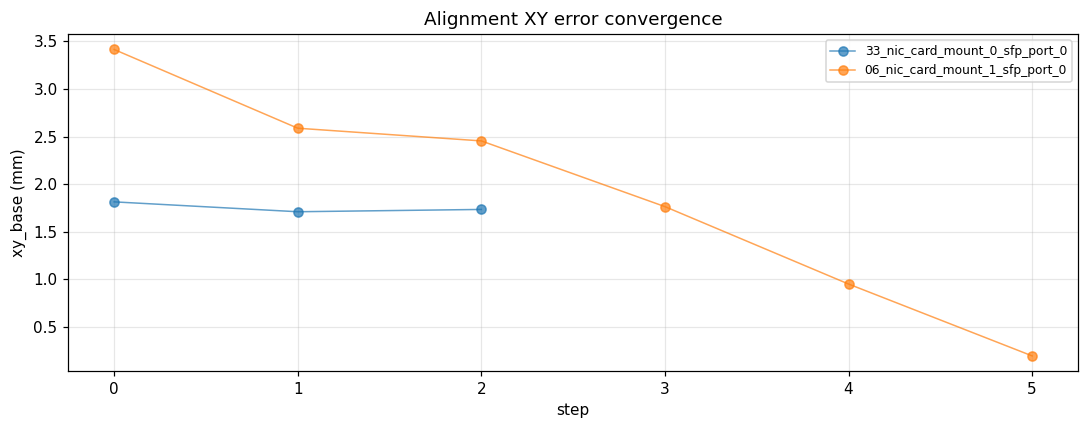

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
for src, g in df_all.groupby("source"):
    ax.plot(g["step"], g["xy_base_mm"], marker="o", linewidth=1.0, alpha=0.7, label=src[-30:])
ax.set_xlabel("step")
ax.set_ylabel("xy_base (mm)")
ax.set_title("Alignment XY error convergence")
ax.grid(True, alpha=0.3)
if df_all["source"].nunique() <= 10:
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 8. 런별 한 줄 요약

In [22]:
agg = df_all.groupby("source").agg(
    steps=("step", "max"),
    t_pred_first=("t_pred_ms", "first"),
    t_pred_median=("t_pred_ms", "median"),
    t_pred_p95=("t_pred_ms", lambda s: np.percentile(s, 95)),
    drift_first=("drift_mm", "first"),
    drift_median=("drift_mm", "median"),
    drift_max=("drift_mm", "max"),
    xy_base_final=("xy_base_mm", "last"),
).round(3)
agg

,steps,t_pred_first,t_pred_median,t_pred_p95,drift_first,drift_median,drift_max,xy_base_final
source,,,,,,,,
align_20260516_044533_nic_card_mount_0_sfp_port_0,2,45.300,42.429,45.013,0.008,0.008,0.027,1.735
align_20260516_044606_nic_card_mount_1_sfp_port_0,5,58.709,40.566,56.999,0.035,0.022,0.047,0.196


## 9. 모델 Bias 추정 및 보정 효과 분석

CSV 에 `pred_raw_*_mm` (보정 전), `pred_*_mm` (보정 후), `bias_*_mm` (적용된 bias) 컬럼이 있어야 합니다.

### 사용 시나리오
1. `bias=0` 으로 실행 → `pred_raw_*` 가 보정 전 모델 출력.
2. plug 가 실제로 포트 정중앙(=0 offset) 일 때의 raw 값을 모음 → 그게 bias 후보.
3. `AIC_DISTANCE_ALIGN_BIAS_*_MM` 환경변수로 그 값 설정 후 재실행 → pred 가 0 근처로.

### 컬럼 호환성 처리
이전 데이터는 raw 컬럼이 없을 수 있어 NaN 으로 처리.

In [23]:
# 새 컬럼이 없는 경우 NaN 으로 채워서 호환 유지 (이전 데이터 호환)
for col in ["pred_raw_x_mm", "pred_raw_y_mm", "pred_raw_z_mm",
            "bias_x_mm", "bias_y_mm", "bias_z_mm"]:
    if col not in df_all.columns:
        df_all[col] = np.nan

# bias 가 0 인 run 만 추출 (raw 가 실제 모델 출력과 동일한 상태)
bias_zero_mask = (
    df_all["bias_x_mm"].fillna(0).abs().lt(1e-6)
    & df_all["bias_y_mm"].fillna(0).abs().lt(1e-6)
    & df_all["bias_z_mm"].fillna(0).abs().lt(1e-6)
)
df_zero = df_all[bias_zero_mask].copy()

print(f"bias=0 인 row: {len(df_zero)} / 전체 {len(df_all)}")
print()
print("=== raw pred 통계 (bias=0 run만) ===")
if len(df_zero) > 0:
    print(df_zero[["pred_raw_x_mm", "pred_raw_y_mm", "pred_raw_z_mm"]].describe(
        percentiles=[0.5, 0.9]).round(3))
else:
    print("bias=0 run 없음 — bias 추정 불가")

bias=0 인 row: 9 / 전체 9

=== raw pred 통계 (bias=0 run만) ===
       pred_raw_x_mm  pred_raw_y_mm  pred_raw_z_mm
count          9.000          9.000          9.000
mean           0.372          1.557        -17.603
std            1.115          0.763          0.719
min           -0.810          0.071        -19.093
50%            0.141          1.687        -17.584
90%            1.433          2.375        -16.921
max            2.877          2.455        -16.589


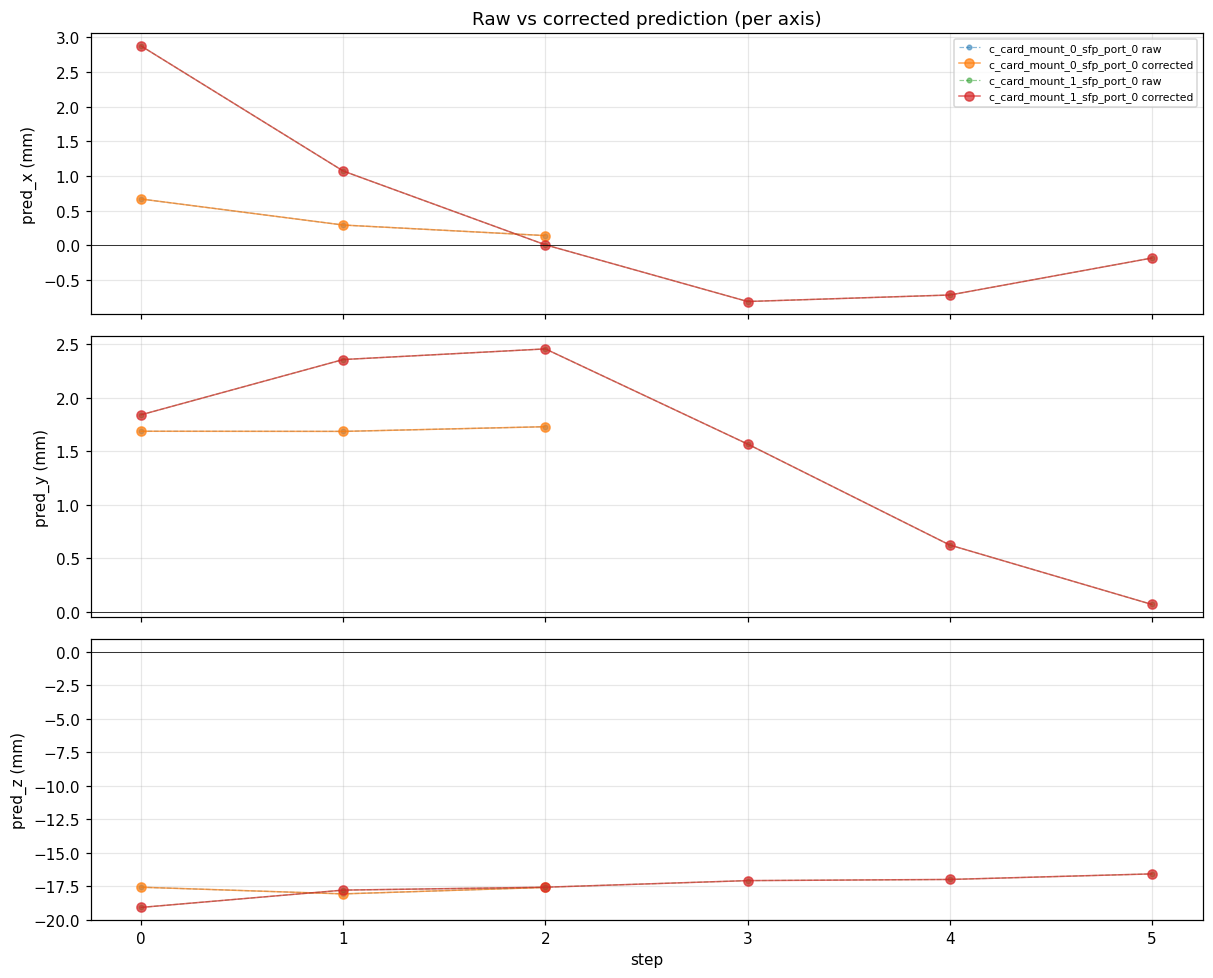

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for axis_name, ax in zip(["x", "y", "z"], axes):
    for src, g in df_all.groupby("source"):
        if g[f"pred_raw_{axis_name}_mm"].notna().any():
            ax.plot(g["step"], g[f"pred_raw_{axis_name}_mm"],
                    marker=".", linestyle="--", linewidth=0.8, alpha=0.5,
                    label=f"{src[-25:]} raw")
        ax.plot(g["step"], g[f"pred_{axis_name}_mm"],
                marker="o", linewidth=1.0, alpha=0.7,
                label=f"{src[-25:]} corrected")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel(f"pred_{axis_name} (mm)")
    ax.grid(True, alpha=0.3)
axes[2].set_xlabel("step")
axes[0].set_title("Raw vs corrected prediction (per axis)")
if df_all["source"].nunique() <= 5:
    axes[0].legend(loc="upper right", fontsize=7)
plt.tight_layout()
plt.show()

In [25]:
# Bias 추정 — 수렴 후반부의 raw pred 의 median
# (수렴했을 때 = 실제 offset 이 작을 때 = raw pred 가 bias 그 자체에 가까움)

# 수렴 후반부 = 각 run 마지막 5 step
tail_n = 5
tail_rows = (
    df_zero.groupby("source", group_keys=False).tail(tail_n)
    if len(df_zero) else df_zero
)

if len(tail_rows) > 0:
    raw_median = tail_rows[["pred_raw_x_mm", "pred_raw_y_mm", "pred_raw_z_mm"]].median()
    raw_iqr = tail_rows[["pred_raw_x_mm", "pred_raw_y_mm", "pred_raw_z_mm"]].quantile([0.25, 0.75])
    print("=== Bias 추정 (각 run 마지막 5 step 의 raw pred median) ===")
    print()
    print(f"  pred_raw_x_mm: median={raw_median['pred_raw_x_mm']:+.2f}mm  "
          f"(IQR={raw_iqr['pred_raw_x_mm'].iloc[0]:+.2f}~{raw_iqr['pred_raw_x_mm'].iloc[1]:+.2f})")
    print(f"  pred_raw_y_mm: median={raw_median['pred_raw_y_mm']:+.2f}mm  "
          f"(IQR={raw_iqr['pred_raw_y_mm'].iloc[0]:+.2f}~{raw_iqr['pred_raw_y_mm'].iloc[1]:+.2f})")
    print(f"  pred_raw_z_mm: median={raw_median['pred_raw_z_mm']:+.2f}mm  "
          f"(IQR={raw_iqr['pred_raw_z_mm'].iloc[0]:+.2f}~{raw_iqr['pred_raw_z_mm'].iloc[1]:+.2f})")
    print()
    print("=== 추천 환경변수 설정 ===")
    print(f"export AIC_DISTANCE_ALIGN_BIAS_X_MM={raw_median['pred_raw_x_mm']:.2f}")
    print(f"export AIC_DISTANCE_ALIGN_BIAS_Y_MM={raw_median['pred_raw_y_mm']:.2f}")
    print(f"# z 는 align 에서 명령 안 함, 0 권장")
    print()
    print("⚠️ 주의: 위 값은 '수렴 후반부' 가정.")
    print("   실제로 plug 가 포트 정중앙인지 시각으로 검증 후 적용 권장.")
else:
    print("분석 가능한 데이터 없음 (bias=0 으로 한 번 실행 필요)")

=== Bias 추정 (각 run 마지막 5 step 의 raw pred median) ===

  pred_raw_x_mm: median=+0.07mm  (IQR=-0.32~+0.39)
  pred_raw_y_mm: median=+1.69mm  (IQR=+1.33~+1.89)
  pred_raw_z_mm: median=-17.58mm  (IQR=-17.65~-17.07)

=== 추천 환경변수 설정 ===
export AIC_DISTANCE_ALIGN_BIAS_X_MM=0.07
export AIC_DISTANCE_ALIGN_BIAS_Y_MM=1.69
# z 는 align 에서 명령 안 함, 0 권장

⚠️ 주의: 위 값은 '수렴 후반부' 가정.
   실제로 plug 가 포트 정중앙인지 시각으로 검증 후 적용 권장.


In [26]:
df_corrected = df_all[~bias_zero_mask].copy()

if len(df_corrected) > 0:
    print("=== bias 적용된 run 의 corrected pred 통계 ===")
    print(df_corrected[["pred_x_mm", "pred_y_mm", "pred_z_mm"]].describe(
        percentiles=[0.5, 0.9]).round(3))
    print()
    print("=== 같은 run 의 raw pred 통계 (보정 전 모델 출력) ===")
    print(df_corrected[["pred_raw_x_mm", "pred_raw_y_mm", "pred_raw_z_mm"]].describe(
        percentiles=[0.5, 0.9]).round(3))
else:
    print("bias 적용된 run 없음 (env 설정 후 실행 필요)")

bias 적용된 run 없음 (env 설정 후 실행 필요)


In [ ]:
# ============================================================
# 10. TCP Motion 분석 — 로봇이 명령대로 움직이는가?
# ============================================================
# 새 컬럼이 없는 (오래된) CSV 호환
for col in ["tcp_x_m", "tcp_y_m", "tcp_z_m",
            "tcp_at_cmd_x_m", "tcp_at_cmd_y_m", "tcp_at_cmd_z_m"]:
    if col not in df_all.columns:
        df_all[col] = np.nan

print("=== TCP 가 있는 run 별 motion 통계 ===")
tcp_avail = df_all.dropna(subset=["tcp_x_m", "tcp_y_m"])
if len(tcp_avail) == 0:
    print("TCP 컬럼이 있는 데이터 없음 (이전 버전 CSV).")
else:
    # 각 run 내에서 step 간 motion 계산
    rows = []
    for src, g in tcp_avail.groupby("source"):
        g = g.sort_values("step").reset_index(drop=True)
        dx = np.diff(g["tcp_x_m"].values) * 1000.0  # mm
        dy = np.diff(g["tcp_y_m"].values) * 1000.0
        dz = np.diff(g["tcp_z_m"].values) * 1000.0
        cmd_x = g["cmd_xy_x_mm"].values[:-1]
        cmd_y = g["cmd_xy_y_mm"].values[:-1]
        for i in range(len(dx)):
            rows.append({
                "source": src,
                "step": int(g["step"].iloc[i]),
                "cmd_x_mm": cmd_x[i],
                "actual_dx_mm": dx[i],
                "tracking_x_ratio": dx[i] / cmd_x[i] if abs(cmd_x[i]) > 0.05 else np.nan,
                "cmd_y_mm": cmd_y[i],
                "actual_dy_mm": dy[i],
                "tracking_y_ratio": dy[i] / cmd_y[i] if abs(cmd_y[i]) > 0.05 else np.nan,
                "actual_dz_mm": dz[i],
            })
    motion_df = pd.DataFrame(rows)
    print(motion_df.to_string())
    print()
    print("=== 명령 추종률 (tracking ratio = actual / cmd) ===")
    print("(1.0 에 가까우면 잘 움직임, 0 에 가까우면 stuck)")
    print()
    print(motion_df[["tracking_x_ratio", "tracking_y_ratio"]].describe(
        percentiles=[0.25, 0.5, 0.75]).round(3))

In [ ]:
# XY plane trajectory (run 별)
tcp_avail = df_all.dropna(subset=["tcp_x_m", "tcp_y_m"])
if len(tcp_avail) > 0:
    fig, ax = plt.subplots(figsize=(8, 8))
    for src, g in tcp_avail.groupby("source"):
        g = g.sort_values("step")
        ax.plot(g["tcp_x_m"] * 1000.0, g["tcp_y_m"] * 1000.0,
                marker="o", linewidth=1.5, alpha=0.7, label=src[-30:])
        # 시작 / 끝 표시
        ax.scatter(g["tcp_x_m"].iloc[0] * 1000.0, g["tcp_y_m"].iloc[0] * 1000.0,
                   marker="s", s=120, edgecolor="black", facecolor="none",
                   label=f"{src[-15:]} start")
        ax.scatter(g["tcp_x_m"].iloc[-1] * 1000.0, g["tcp_y_m"].iloc[-1] * 1000.0,
                   marker="*", s=200, edgecolor="black",
                   label=f"{src[-15:]} end")
    ax.set_xlabel("TCP x (mm)")
    ax.set_ylabel("TCP y (mm)")
    ax.set_title("TCP XY trajectory per run")
    ax.set_aspect("equal", adjustable="datalim")
    ax.grid(True, alpha=0.3)
    if tcp_avail["source"].nunique() <= 5:
        ax.legend(loc="best", fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    print("TCP 데이터 없음.")

In [ ]:
# Cmd vs Actual motion 비교 (run 별, y 축 중심)
if 'motion_df' in dir() and len(motion_df) > 0:
    n_runs = motion_df["source"].nunique()
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    for src, g in motion_df.groupby("source"):
        axes[0].plot(g["step"], g["cmd_y_mm"],
                     marker="o", linestyle="--", linewidth=1.0, alpha=0.7,
                     label=f"{src[-25:]} cmd_y")
        axes[0].plot(g["step"], g["actual_dy_mm"],
                     marker="x", linewidth=1.0, alpha=0.7,
                     label=f"{src[-25:]} actual_dy")
    axes[0].axhline(0, color="black", linewidth=0.5)
    axes[0].set_ylabel("y motion (mm)")
    axes[0].set_title("Commanded vs actual Δy per step (큰 차이 = stuck/saturation)")
    axes[0].grid(True, alpha=0.3)
    if n_runs <= 4:
        axes[0].legend(loc="best", fontsize=7)

    for src, g in motion_df.groupby("source"):
        axes[1].plot(g["step"], g["tracking_y_ratio"],
                     marker="o", linewidth=1.0, alpha=0.7, label=src[-30:])
    axes[1].axhline(1.0, color="green", linewidth=0.5, label="ideal=1.0")
    axes[1].axhline(0.0, color="red", linewidth=0.5, label="stuck=0.0")
    axes[1].set_ylabel("tracking_y_ratio")
    axes[1].set_xlabel("step")
    axes[1].set_title("Tracking ratio (actual / cmd): 1.0 이상적, 0 = stuck")
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(-0.5, 2.0)
    if n_runs <= 5:
        axes[1].legend(loc="best", fontsize=7)
    plt.tight_layout()
    plt.show()

## 11. Mount(레일) 별 비교 — Per-Rail Bias 가설 검증

`target_module_name` 의 mount 인덱스 (`nic_card_mount_N` 의 N) 별로 그룹화해서 정리합니다.

- **pred_raw_y_median** 이 mount 별로 다르면 → systematic bias 의 mount 의존성 증거.
- **xy_base_final** 이 mount 별로 다르면 → 수렴 성공률 차이.
- **tracking_y_ratio** 가 mount 별로 다르면 → mechanical 환경 차이 (cable/friction).
- 세 가지를 종합해서 **"model bias vs mechanical stuck"** 의 진짜 원인 분리.

In [ ]:
# Mount 인덱스 추출 (source 또는 task 컬럼에서)
df_all["mount_idx"] = (
    df_all["source"].str.extract(r"mount_(\d+)").astype(float)
)
df_all["port_type"] = np.where(
    df_all["source"].str.contains("sc_port", na=False), "sc", "sfp"
)

# Mount 별 집계 (SFP run 만)
df_sfp = df_all[df_all["port_type"] == "sfp"].copy()
if len(df_sfp) == 0:
    print("SFP run 없음.")
else:
    # 각 source 의 마지막 step (수렴 후반부) 만으로 final 값
    last_per_run = df_sfp.groupby("source", as_index=False).tail(1)

    # tail (마지막 5 step) 으로 raw pred median
    tail_per_run = df_sfp.groupby("source", group_keys=False).tail(5)

    mount_summary = (
        tail_per_run.groupby("mount_idx").agg(
            n_runs=("source", "nunique"),
            n_steps=("step", "count"),
            pred_raw_x_med=("pred_raw_x_mm", "median"),
            pred_raw_y_med=("pred_raw_y_mm", "median"),
            pred_raw_x_iqr=("pred_raw_x_mm", lambda s: s.quantile(0.75) - s.quantile(0.25)),
            pred_raw_y_iqr=("pred_raw_y_mm", lambda s: s.quantile(0.75) - s.quantile(0.25)),
        ).round(3)
    )

    # xy_base_final 별도 (각 run 의 last)
    xy_final = (
        last_per_run.groupby("mount_idx")["xy_base_mm"].median().round(3)
    )
    mount_summary["xy_base_final_med"] = xy_final

    print("=== Mount 별 요약 (수렴 후반부 raw pred median + 최종 xy_base) ===")
    print(mount_summary.to_string())
    print()

    # Mount 간 편차 정도
    if len(mount_summary) > 1:
        y_spread = mount_summary["pred_raw_y_med"].max() - mount_summary["pred_raw_y_med"].min()
        x_spread = mount_summary["pred_raw_x_med"].max() - mount_summary["pred_raw_x_med"].min()
        print(f"=== Mount 간 raw pred 편차 ===")
        print(f"  X: {x_spread:.2f}mm")
        print(f"  Y: {y_spread:.2f}mm")
        print()
        if y_spread > 1.0 or x_spread > 1.0:
            print("⚠️ Mount 별 편차 > 1mm → per-rail bias 가능성 높음")
            print("   → config 의 ALIGN_BIAS_*_MM 을 mount 별로 분리 권장")
        else:
            print("✓ Mount 별 편차 < 1mm → 통일된 bias 또는 noise 수준")

## 해석 가이드

| 관찰 | 의미 | 액션 |
|------|------|------|
| `t_pred_first` ≫ `t_pred_median` | Lazy init | 워밍업 추가 |
| `t_pred_median` > 50ms | 추론 자체 느림 | FP16/TensorRT/입력 축소 |
| `drift_first` 큼, `drift_median` 작음 | 첫 스텝 잔여 모션 | approach SETTLE 늘리기 또는 워밍업 |
| `drift_median` > 0.5mm | 동기 추론이 정밀도에 영향 | 명령 직전 TCP 기준 step 보상, 또는 비동기화 |
| Pearson r > 0.5 (drift vs t_pred) | 동기 추론이 drift 의 주요 원인 | 위 동일 |
| `xy_base_final` > ALIGN_FINISH_XY_M | 수렴 실패 | 모델 정확도/게인/타임아웃 검토 |
| 모든 drift = 0 정확히 | obs 캐시 미갱신 가능성 | 캐시 publish rate 확인 |